# Neural Networks Training for Classification Task

## Group Members - Group 5

| Name                   | Email |
|:-----------------------|:------|
| Nicolas Martinez Lopez | nmartinezl@unal.edu.co|
| Anna Martina Visone    |avisone@unal.edu.co|
| Miller Barrera González|mbarrerag@unal.edu.co|
| Sergio Castro Vargas   |secastrov@unal.edu.co|

# **Libraries**

In [403]:
!pip install -q pytorch-tabnet

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

In [404]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# **Load Dataset**

In [405]:
dataset_url = "https://raw.githubusercontent.com/nmart1nezl/DataMiningProject/refs/heads/main/datasets/classifiers_dataset.csv"
df = pd.read_csv(dataset_url)
df.head()

,Unnamed: 0,category,age,industries,countryOfCitizenship,selfMade,gender,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,total_tax_rate_country,population_country,number_of_companies,finalWorth_category,is_founder,is_ceo,is_chairman,is_investor,is_entrepreneur,cpi_country_log,tax_revenue_country_country_log
0,0,Fashion & Retail,74.080767,Consumer Discretionary,France,False,M,1.1,2.715518e+12,65.6,102.5,82.5,60.7,67059887.0,75,muy alto,0,1,1,0,0,4.709981,3.226844
1,1,Automotive,51.767283,Consumer Discretionary,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,7,muy alto,1,1,0,0,0,4.772716,2.360854
2,2,Technology,59.225188,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,100,muy alto,1,0,0,0,0,4.772716,2.360854
3,3,Technology,78.628337,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,5,muy alto,1,0,1,0,0,4.772716,2.360854
4,4,Finance & Investments,92.594114,Financials & Investments,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,60,muy alto,0,1,1,0,0,4.772716,2.360854


In [406]:
pd.set_option('display.max_columns', None)
display(df.head())

,Unnamed: 0,category,age,industries,countryOfCitizenship,selfMade,gender,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,total_tax_rate_country,population_country,number_of_companies,finalWorth_category,is_founder,is_ceo,is_chairman,is_investor,is_entrepreneur,cpi_country_log,tax_revenue_country_country_log
0,0,Fashion & Retail,74.080767,Consumer Discretionary,France,False,M,1.1,2.715518e+12,65.6,102.5,82.5,60.7,67059887.0,75,muy alto,0,1,1,0,0,4.709981,3.226844
1,1,Automotive,51.767283,Consumer Discretionary,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,7,muy alto,1,1,0,0,0,4.772716,2.360854
2,2,Technology,59.225188,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,100,muy alto,1,0,0,0,0,4.772716,2.360854
3,3,Technology,78.628337,Technology & Telecommunications,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,5,muy alto,1,0,1,0,0,4.772716,2.360854
4,4,Finance & Investments,92.594114,Financials & Investments,United States,True,M,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,60,muy alto,0,1,1,0,0,4.772716,2.360854


In [407]:
display(df.columns)

Index(['Unnamed: 0', 'category', 'age', 'industries', 'countryOfCitizenship',
       'selfMade', 'gender', 'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'total_tax_rate_country', 'population_country', 'number_of_companies',
       'finalWorth_category', 'is_founder', 'is_ceo', 'is_chairman',
       'is_investor', 'is_entrepreneur', 'cpi_country_log',
       'tax_revenue_country_country_log'],
      dtype='object')

In [408]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()}")

category: ['Fashion & Retail' 'Automotive' 'Technology' 'Finance & Investments'
 'Telecom' 'Diversified' 'Food & Beverage' 'Media & Entertainment'
 'Logistics' 'Gambling & Casinos' 'Manufacturing' 'Real Estate'
 'Metals & Mining' 'Energy' 'Healthcare' 'Sports'
 'Construction & Engineering' 'Service']
industries: ['Consumer Discretionary' 'Technology & Telecommunications'
 'Financials & Investments' 'Media, Entertainment & Leisure' 'Other'
 'Consumer Staples' nan 'Industrials & Manufacturing'
 'Real Estate & Construction' 'Energy & Natural Resources' 'Healthcare']
countryOfCitizenship: ['France' 'United States' 'Mexico' 'India' 'Spain' 'China' 'Canada'
 'Germany' 'Italy' 'Hong Kong' 'Austria' 'Japan' 'Switzerland' 'Australia'
 'Indonesia' 'Russia' 'Chile' 'United Kingdom' 'Israel' 'Brazil'
 'Czech Republic' 'Singapore' 'Sweden' 'Thailand' 'Netherlands' 'Nigeria'
 'Cyprus' 'Malaysia' 'United Arab Emirates' 'South Africa' 'New Zealand'
 'Philippines' 'Monaco' 'Belgium' 'South Korea' 'Taiw

In [409]:
# Reload the original dataset to ensure we are working with the unencoded 'countryOfCitizenship' column
temp_df_for_unique = pd.read_csv(dataset_url)

# Get the frequency of each unique country from the original column
country_frequencies = temp_df_for_unique['countryOfCitizenship'].value_counts()

print("Frecuencia por cada país (del dataset original):")
for country, count in country_frequencies.items():
    print(f"  {country}: {count}")

Frecuencia por cada país (del dataset original):
  United States: 735
  China: 489
  India: 169
  Germany: 126
  Russia: 104
  Hong Kong: 68
  Italy: 64
  Canada: 63
  United Kingdom: 52
  Taiwan: 52
  Brazil: 51
  Australia: 47
  France: 43
  Switzerland: 41
  Japan: 40
  Sweden: 39
  Singapore: 37
  South Korea: 30
  Israel: 30
  Indonesia: 29
  Thailand: 28
  Spain: 27
  Turkey: 26
  Malaysia: 18
  Mexico: 14
  Philippines: 14
  Netherlands: 12
  Norway: 12
  Austria: 11
  Czech Republic: 11
  Ireland: 9
  Cyprus: 9
  Denmark: 8
  Poland: 7
  Chile: 7
  Finland: 7
  Egypt: 6
  Kazakhstan: 6
  Vietnam: 6
  Romania: 6
  Lebanon: 6
  Greece: 6
  Argentina: 5
  South Africa: 5
  Ukraine: 5
  Belgium: 4
  Colombia: 4
  United Arab Emirates: 4
  Peru: 4
  Hungary: 3
  New Zealand: 3
  Monaco: 3
  Nigeria: 3
  Slovakia: 2
  Bulgaria: 2
  Qatar: 2
  Morocco: 2
  Georgia: 2
  Oman: 2
  Eswatini (Swaziland): 1
  Venezuela: 1
  Liechtenstein: 1
  Guernsey: 1
  Iceland: 1
  Belize: 1
  Algeria:

In [410]:
df['finalWorth_category']

,finalWorth_category
0,muy alto
1,muy alto
2,muy alto
3,muy alto
4,muy alto
...,...
2633,muy bajo
2634,muy bajo
2635,muy bajo
2636,muy bajo


## Preprocess Dataset

### Convert Categorical Columns to Numeric

In [411]:
# Drop 'Unnamed: 0' as it appears to be an index column
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('is_founder', axis=1)
df = df.drop('is_entrepreneur', axis=1)

# Ordinal encoding for 'finalWorth_category'
WORTH_ORDER = ["muy bajo", "bajo", "medio", "alto", "muy alto"]
worth_map = {v: i for i, v in enumerate(WORTH_ORDER)}
df['finalWorth_category'] = df['finalWorth_category'].map(worth_map)

# Handle missing values in 'industries' by filling with 'Unknown' before one-hot encoding
df['industries'] = df['industries'].fillna('Unknown')

# Group low-frequency countries in 'countryOfCitizenship' into 'Other_Countries'
# Calculate country frequencies
country_counts = df['countryOfCitizenship'].value_counts()
# Identify countries with frequency less than 10
low_frequency_countries = country_counts[country_counts < 10].index.tolist()
# Replace these countries with 'Other_Countries'
df['countryOfCitizenship'] = df['countryOfCitizenship'].replace(low_frequency_countries, 'Other')

# One-Hot Encoding for other nominal categorical variables
categorical_cols_to_encode = ['countryOfCitizenship', 'gender', 'category', 'industries']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=False)

print("DataFrame after preprocessing categorical features:")
display(df.head())
print(f"New shape of df: {df.shape}")

DataFrame after preprocessing categorical features:


,age,selfMade,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,total_tax_rate_country,population_country,number_of_companies,finalWorth_category,is_ceo,is_chairman,is_investor,cpi_country_log,tax_revenue_country_country_log,countryOfCitizenship_Australia,countryOfCitizenship_Austria,countryOfCitizenship_Brazil,countryOfCitizenship_Canada,countryOfCitizenship_China,countryOfCitizenship_Czech Republic,countryOfCitizenship_France,countryOfCitizenship_Germany,countryOfCitizenship_Hong Kong,countryOfCitizenship_India,countryOfCitizenship_Indonesia,countryOfCitizenship_Israel,countryOfCitizenship_Italy,countryOfCitizenship_Japan,countryOfCitizenship_Malaysia,countryOfCitizenship_Mexico,countryOfCitizenship_Netherlands,countryOfCitizenship_Norway,countryOfCitizenship_Other,countryOfCitizenship_Philippines,countryOfCitizenship_Russia,countryOfCitizenship_Singapore,countryOfCitizenship_South Korea,countryOfCitizenship_Spain,countryOfCitizenship_Sweden,countryOfCitizenship_Switzerland,countryOfCitizenship_Taiwan,countryOfCitizenship_Thailand,countryOfCitizenship_Turkey,countryOfCitizenship_United Kingdom,countryOfCitizenship_United States,gender_F,gender_M,category_Automotive,category_Construction & Engineering,category_Diversified,category_Energy,category_Fashion & Retail,category_Finance & Investments,category_Food & Beverage,category_Gambling & Casinos,category_Healthcare,category_Logistics,category_Manufacturing,category_Media & Entertainment,category_Metals & Mining,category_Real Estate,category_Service,category_Sports,category_Technology,category_Telecom,industries_Consumer Discretionary,industries_Consumer Staples,industries_Energy & Natural Resources,industries_Financials & Investments,industries_Healthcare,industries_Industrials & Manufacturing,"industries_Media, Entertainment & Leisure",industries_Other,industries_Real Estate & Construction,industries_Technology & Telecommunications,industries_Unknown
0,74.080767,False,1.1,2.715518e+12,65.6,102.5,82.5,60.7,67059887.0,75,4,1,1,0,4.709981,3.226844,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,51.767283,True,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,7,4,1,0,0,4.772716,2.360854,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,59.225188,True,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,100,4,0,0,0,4.772716,2.360854,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
3,78.628337,True,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,5,4,0,1,0,4.772716,2.360854,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,92.594114,True,7.5,2.142770e+13,88.2,101.8,78.5,36.6,328239523.0,60,4,1,1,0,4.772716,2.360854,False,False,False,False,False

New shape of df: (2638, 78)


### Apply StandardScaler to Numeric Columns

In [412]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'finalWorth_category' as it's the target variable and already processed
numeric_cols.remove('is_ceo')
numeric_cols.remove('is_chairman')
numeric_cols.remove('is_investor')

if 'finalWorth_category' in numeric_cols:
    numeric_cols.remove('finalWorth_category')

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("DataFrame after applying StandardScaler to numeric columns:")
display(df.head())

DataFrame after applying StandardScaler to numeric columns:


,age,selfMade,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,total_tax_rate_country,population_country,number_of_companies,finalWorth_category,is_ceo,is_chairman,is_investor,cpi_country_log,tax_revenue_country_country_log,countryOfCitizenship_Australia,countryOfCitizenship_Austria,countryOfCitizenship_Brazil,countryOfCitizenship_Canada,countryOfCitizenship_China,countryOfCitizenship_Czech Republic,countryOfCitizenship_France,countryOfCitizenship_Germany,countryOfCitizenship_Hong Kong,countryOfCitizenship_India,countryOfCitizenship_Indonesia,countryOfCitizenship_Israel,countryOfCitizenship_Italy,countryOfCitizenship_Japan,countryOfCitizenship_Malaysia,countryOfCitizenship_Mexico,countryOfCitizenship_Netherlands,countryOfCitizenship_Norway,countryOfCitizenship_Other,countryOfCitizenship_Philippines,countryOfCitizenship_Russia,countryOfCitizenship_Singapore,countryOfCitizenship_South Korea,countryOfCitizenship_Spain,countryOfCitizenship_Sweden,countryOfCitizenship_Switzerland,countryOfCitizenship_Taiwan,countryOfCitizenship_Thailand,countryOfCitizenship_Turkey,countryOfCitizenship_United Kingdom,countryOfCitizenship_United States,gender_F,gender_M,category_Automotive,category_Construction & Engineering,category_Diversified,category_Energy,category_Fashion & Retail,category_Finance & Investments,category_Food & Beverage,category_Gambling & Casinos,category_Healthcare,category_Logistics,category_Manufacturing,category_Media & Entertainment,category_Metals & Mining,category_Real Estate,category_Service,category_Sports,category_Technology,category_Telecom,industries_Consumer Discretionary,industries_Consumer Staples,industries_Energy & Natural Resources,industries_Financials & Investments,industries_Healthcare,industries_Industrials & Manufacturing,"industries_Media, Entertainment & Leisure",industries_Other,industries_Real Estate & Construction,industries_Technology & Telecommunications,industries_Unknown
0,0.644865,False,-0.893347,-0.962938,-0.074819,-0.068798,1.196278,1.432627,-0.794146,22.771087,4,1,1,0,-0.761051,1.893639,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,-1.061382,True,0.920135,1.004495,1.017367,-0.221842,0.094139,-0.616237,-0.310987,1.643702,4,1,0,0,-0.385320,-0.462580,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,-0.491098,True,0.920135,1.004495,1.017367,-0.221842,0.094139,-0.616237,-0.310987,30.538508,4,0,0,0,-0.385320,-0.462580,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
3,0.992605,True,0.920135,1.004495,1.017367,-0.221842,0.094139,-0.616237,-0.310987,1.022308,4,0,1,0,-0.385320,-0.462580,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,2.060527,True,0.920135,1

In [413]:
df.shape

(2638, 78)

In [414]:
df.columns

Index(['age', 'selfMade', 'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'total_tax_rate_country', 'population_country', 'number_of_companies',
       'finalWorth_category', 'is_ceo', 'is_chairman', 'is_investor',
       'cpi_country_log', 'tax_revenue_country_country_log',
       'countryOfCitizenship_Australia', 'countryOfCitizenship_Austria',
       'countryOfCitizenship_Brazil', 'countryOfCitizenship_Canada',
       'countryOfCitizenship_China', 'countryOfCitizenship_Czech Republic',
       'countryOfCitizenship_France', 'countryOfCitizenship_Germany',
       'countryOfCitizenship_Hong Kong', 'countryOfCitizenship_India',
       'countryOfCitizenship_Indonesia', 'countryOfCitizenship_Israel',
       'countryOfCitizenship_Italy', 'countryOfCitizenship_Japan',
       'countryOfCitizenship_Malaysia', 'countryOfCitizenship_Mexico',
       'countryOfCitizenship_Neth

In [415]:
df['finalWorth_category']

,finalWorth_category
0,4
1,4
2,4
3,4
4,4
...,...
2633,0
2634,0
2635,0
2636,0


# **Divide Dataset into Training, Validation and Test Datasets**

In [416]:
# Divide dataset into X and Y
Y = df['selfMade']

X = df.drop('selfMade', axis=1)
X = X.astype(np.float32)

# Map industries to numerical output using LabelEncoder

# Split data into training (70%), validation (15%) and test (15%) sets
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

print(f"Training set shape: X={X_train.shape}, Y={Y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, Y={Y_val.shape}")
print(f"Test set shape: X={X_test.shape}, Y={Y_test.shape}")

Training set shape: X=(1846, 77), Y=(1846,)
Validation set shape: X=(396, 77), Y=(396,)
Test set shape: X=(396, 77), Y=(396,)


# **Neural Networks Training**

We will train and evaluate two different neural networks for the classification task: a classic Multilayer Perceptron (MLP) and a TabNet model. Both architectures will be trained, and their results will be verified to compare their performance.

## Classic MLP with Regularization

### Define Neural Network Model Architecture

In [417]:
model_nn = keras.Sequential([
    keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4), input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.4),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    keras.layers.Dropout(0.4),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(2, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=7e-3)

model_nn.compile(optimizer=optimizer,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model_nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,138 (74.76 KB)

 Trainable params: 18,754 (73.26 KB)

 Non-trainable params: 384 (1.50 KB)

### Train Neural Network Model

In [418]:
history_nn = model_nn.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_val, Y_val), verbose=1)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8283 - loss: 0.4128 - val_accuracy: 0.9268 - val_loss: 0.2544
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9301 - loss: 0.2137 - val_accuracy: 0.9369 - val_loss: 0.2002
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9350 - loss: 0.1866 - val_accuracy: 0.9571 - val_loss: 0.1457
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9572 - loss: 0.1591 - val_accuracy: 0.9520 - val_loss: 0.1402
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9572 - loss: 0.1399 - val_accuracy: 0.9495 - val_loss: 0.1457
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9540 - loss: 0.1404 - val_accuracy: 0.9470 - val_loss: 0.1535
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9550 - loss: 0.1444 - val_accuracy: 0.9545 - val_loss: 0.1346
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9540 - loss: 0.1463 - val_accuracy: 0.9470 - v

### Function to Visualize Training History

In [419]:
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Precisión del Modelo')
    plt.ylabel('Precisión')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Pérdida del Modelo')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

### Visualize Neural Network Training History

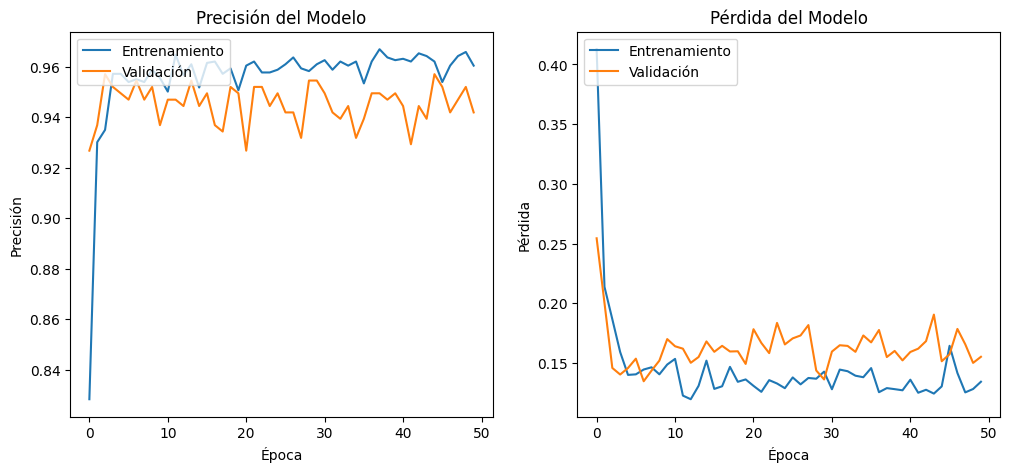

In [420]:
plot_training_history(history_nn)

### Evaluate Neural Network Model on Test Set

In [421]:
loss_test_nn, accuracy_test_nn = model_nn.evaluate(X_test, Y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba (Test Loss): {loss_test_nn:.4f}")
print(f"Precisión en el conjunto de prueba (Test Accuracy): {accuracy_test_nn:.4f}")

Pérdida en el conjunto de prueba (Test Loss): 0.1722
Precisión en el conjunto de prueba (Test Accuracy): 0.9419


### Results with whole dataset

In [422]:
# Make predictions on the entire preprocessed dataset
X_np = X.values # Assuming X is your full preprocessed dataframe
Y_pred_full_dataset = clf.predict(X_np)

# Generate and print the classification report
print("--- Classification Report for Entire Dataset ---")
print(classification_report(Y, Y_pred_full_dataset))

--- Classification Report for Entire Dataset ---
              precision    recall  f1-score   support

       False       0.91      0.93      0.92       827
        True       0.97      0.96      0.96      1811

    accuracy                           0.95      2638
   macro avg       0.94      0.95      0.94      2638
weighted avg       0.95      0.95      0.95      2638



## TabNet

### Define TabNet Model Architecture

In [423]:
# TabNet requires numpy arrays, so convert X_train, Y_train, etc., to numpy arrays
X_train_np = X_train.values
Y_train_np = Y_train
X_val_np = X_val.values
Y_val_np = Y_val
X_test_np = X_test.values
Y_test_np = Y_test

# Instantiate TabNetClassifier
clf = TabNetClassifier(n_d=32, n_a=32, n_steps=5, gamma=1.3,
                       optimizer_fn=torch.optim.Adam,
                       optimizer_params=dict(lr=2e-2),
                       scheduler_params={"step_size":50, "gamma":0.9},
                       scheduler_fn=torch.optim.lr_scheduler.StepLR,
                       mask_type='sparsemax' # This is the default, but good to be explicit
                      )

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


### Train TabNet Model

In [424]:
max_epochs = 20

# Fit the TabNet model
clf.fit(
    X_train_np, Y_train_np,
    eval_set=[(X_train_np, Y_train_np), (X_val_np, Y_val_np)],
    eval_name=['train', 'valid'],
    max_epochs=max_epochs,
    patience=20, # Early stopping if validation metric does not improve for 20 epochs
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

epoch 0  | loss: 1.05319 | train_auc: 0.54344 | valid_auc: 0.49535 |  0:00:00s
epoch 1  | loss: 0.80426 | train_auc: 0.61673 | valid_auc: 0.58011 |  0:00:01s
epoch 2  | loss: 0.79602 | train_auc: 0.68305 | valid_auc: 0.62109 |  0:00:01s
epoch 3  | loss: 0.67315 | train_auc: 0.68095 | valid_auc: 0.63241 |  0:00:02s
epoch 4  | loss: 0.58096 | train_auc: 0.72529 | valid_auc: 0.70025 |  0:00:02s
epoch 5  | loss: 0.51791 | train_auc: 0.83067 | valid_auc: 0.79112 |  0:00:02s
epoch 6  | loss: 0.4594  | train_auc: 0.87902 | valid_auc: 0.86492 |  0:00:03s
epoch 7  | loss: 0.40875 | train_auc: 0.90625 | valid_auc: 0.88908 |  0:00:03s
epoch 8  | loss: 0.34173 | train_auc: 0.93209 | valid_auc: 0.92712 |  0:00:04s
epoch 9  | loss: 0.32433 | train_auc: 0.94113 | valid_auc: 0.94046 |  0:00:04s
epoch 10 | loss: 0.27531 | train_auc: 0.95864 | valid_auc: 0.95413 |  0:00:05s
epoch 11 | loss: 0.24315 | train_auc: 0.96644 | valid_auc: 0.9571  |  0:00:05s
epoch 12 | loss: 0.23363 | train_auc: 0.96849 | vali

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


### Visualize Training/Validation Results

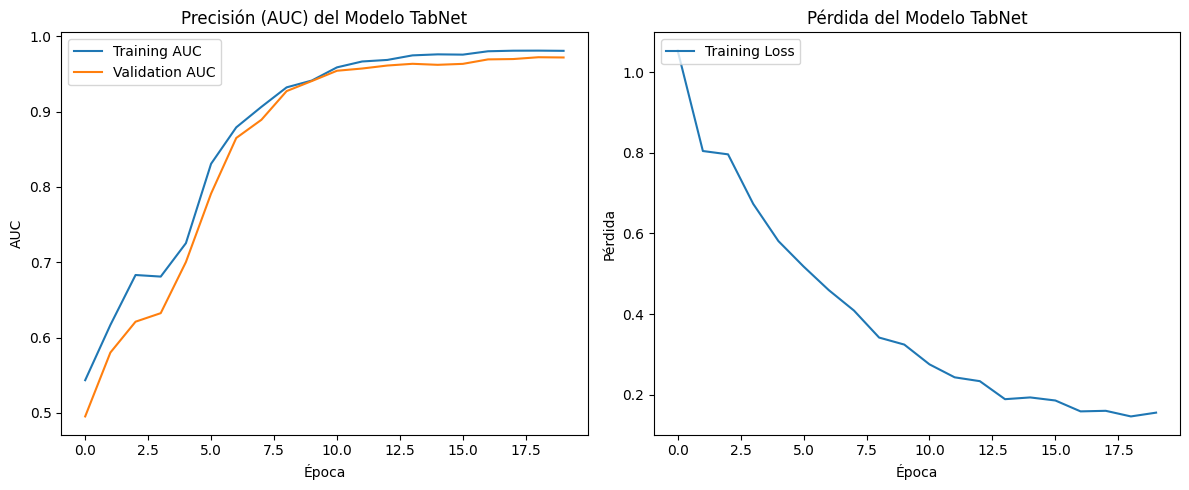

In [425]:
history_tabnet = clf.history

plt.figure(figsize=(12, 5))

# Plot training & validation AUC values
plt.subplot(1, 2, 1)
plt.plot(history_tabnet['train_auc'], label='Training AUC')
plt.plot(history_tabnet['valid_auc'], label='Validation AUC')
plt.title('Precisión (AUC) del Modelo TabNet')
plt.ylabel('AUC')
plt.xlabel('Época')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_tabnet['loss'], label='Training Loss')
# Note: TabNet history often doesn't directly provide 'val_loss' in the same way Keras does,
# but 'loss' represents the training loss per epoch. If a separate validation loss was available
# it would be plotted here.
plt.title('Pérdida del Modelo TabNet')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Evaluate TabNet Model on Test Set

In [426]:
preds_test = clf.predict(X_test_np)
preds_proba_test = clf.predict_proba(X_test_np)

# Evaluate the model
accuracy_test_tabnet = accuracy_score(Y_test_np, preds_test)
print(f"Precisión en el conjunto de prueba (Test Accuracy - TabNet): {accuracy_test_tabnet:.4f}")

Precisión en el conjunto de prueba (Test Accuracy - TabNet): 0.9268


In [427]:
# Make predictions on the test dataset using the trained TabNet classifier
Y_pred_test_tabnet = clf.predict(X_test_np)

# Generate and print the classification report for the test set
print("--- Classification Report for TabNet on Test Set ---")
print(classification_report(Y_test_np, Y_pred_test_tabnet))

--- Classification Report for TabNet on Test Set ---
              precision    recall  f1-score   support

       False       0.87      0.90      0.89       124
        True       0.96      0.94      0.95       272

    accuracy                           0.93       396
   macro avg       0.91      0.92      0.92       396
weighted avg       0.93      0.93      0.93       396

